<img src="https://github.com/nekowaneko/teacher_test/blob/main/%E4%BD%A0%E5%B7%B2%E7%B6%93%E5%AD%B8%E6%9C%83%E5%85%A8%E9%83%A8%E7%9A%84%E5%9F%BA%E6%9C%AC%E6%93%8D%E4%BD%9C.jpg?raw=true" width="300px">

## <font color=#ff00ff> 利用矩陣算出各種最適直線 </font>

### <center> 對於最簡單的最適直線(當然，有複雜的)--線性回歸來說，其方程式如下: </center>

$$ y = m_0+m_1 x $$
 
#### <center> 其中 $ x $ = 操縱變因 & $ y $ = 應變變因</center>

$$ \mathbf G  = \begin{bmatrix} 1 & x_1 \\ 1 & x_2  \\ \vdots  & \vdots \\ 1 & x_n  \end{bmatrix}, 
\mathbf m= \begin{bmatrix} m_0\\ m_1 \end{bmatrix}, \mathbf d  = \begin{bmatrix} y_1\\ y_2 \\ \vdots \\ y_n  \end{bmatrix}$$


### <center>m 是我們要求的方程式係數，所幸前人給出了解法，此解法適合處理 over-determined  problem。 </center>

## over-determined  problem : 

### <center>此方法的計算原理採用最小平方法。 </center>

$$ \mathbf m = [\mathbf G^{\mathbf T}\mathbf G]^{-1}\mathbf G^{\mathbf T}\mathbf d  $$

### 問題:如何產生 $$ \mathbf G  = \begin{bmatrix} 1 & x_1 \\ 1 & x_2  \\ \vdots  & \vdots \\ 1 & x_n  \end{bmatrix}$$


In [14]:
# 沿用之前設定的x_values
x = x_values

# 使用np.full(shape,fill value)函數，填充1在矩陣中
const = np.full((1,len(x_values)),1) 

print(const) # 可以看到矩陣const的形狀

G_temp = np.vstack([const,x]) # 使用np.vstack將兩個np.array組合
print(G_temp)                 # 可以看到G_temp的形狀

G = G_temp.T                  # 將其轉置即可得到G
print(G)

[[1 1 1 1 1]]
[[1 1 1 1 1]
 [1 2 3 4 5]]
[[1 1]
 [1 2]
 [1 3]
 [1 4]
 [1 5]]


In [15]:
# 沿用之前設定的y_values(代表測量的平均值)
y = y_values
d = y.T
print(d)

m = (np.linalg.inv(G.T.dot(G))).dot(G.T).dot(d)

print(m)

[10.2        12.5        15.         17.63333333 20.3       ]
[7.52666667 2.53333333]


## <font color=#ff00ff>在散佈圖上呈現最適直線與相關係數 </font>

### 快做好了，加油。

### 經過上述的計算，我們知道

$$ y = m_0+m_1 x $$
$$ m[0] = m_0 ;m[1] = m_1  $$

### 透過以下四步驟，就可以將數據完整呈現在散佈圖上，並儲存成png檔案

### step1: 
* 產生一個xx array，將x從最小值到最大值切成100等分 

In [16]:
xx=np.linspace(x.min(),x.max(),100)  #用np.linspace()函數在x的最大值與最小值間切出100個等距的值

### step2: 
* 經由最適直線預測出操縱變因理應測量到的值

In [17]:
yy = m[0]+m[1]*xx
print(f'最適直線為 y={m[1]} x + {m[0]}')

最適直線為 y=2.533333333333335 x + 7.5266666666666815


### step3:
* 計算測量值與回歸值線間的整體偏移量   E

$$ E =  \sum_{i=1}^{n}(\mathbf e_i)^2=  \sum_{i=1}^{n}(\mathbf d - \mathbf G \mathbf m )^2$$

* 算出相關係數(correlation coefficient)

相關係數 ($ R^2 $) 的公式如下: 
$$ R^2 = 1-E / \sum_{i=1}^{n} (d-mean(d))^2 $$

* 請問這個數值代表著什麼意義？

代表此最適直線可以解釋大約 $ R^2 $ 比例的數據結果。

In [18]:
# Calculate the error vector
e = d - G.dot(m)
    
# Compute the squared error and the root mean square error
E = np.sum(e**2)

R_squart = 1 - E/np.sum((d-np.mean(d))**2)

print(r"相關係數(R^2)是 {:.2f}".format(R_squart))

相關係數(R^2)是 1.00


### step4: 
* 將最適直線與相關係數呈現在散佈圖上，並儲存成png檔案

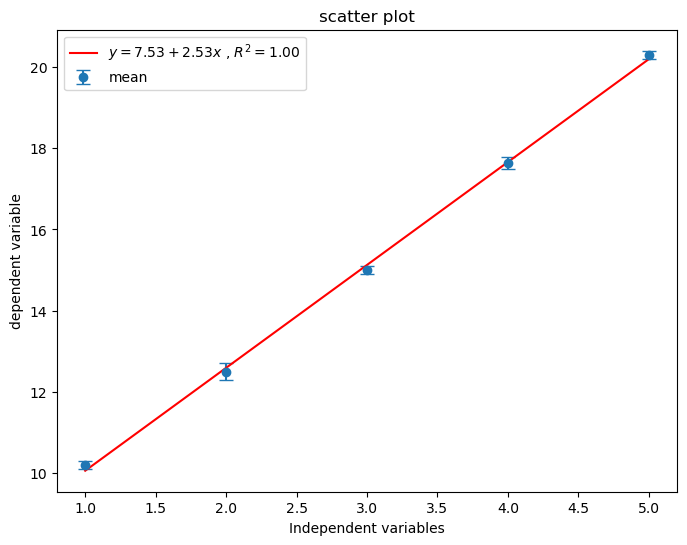

In [19]:
plt.figure(figsize=(8, 6))

plt.errorbar(x_values, y_values, yerr=stds, fmt='o', capsize=5, label='mean')
plt.plot(xx, yy, '-', color='red', label= r"$y={:.2f}+{:.2f}x$ , $R^2={:.2f}$".format(m[0].item(), m[1].item(), R_squart))

plt.title('scatter plot')
plt.xlabel('Independent variables')
plt.ylabel('dependent variable')
plt.legend()
plt.savefig('textbook.png')
plt.show()


### step bonus:
* 上述方法可以應用在任何類型的回歸線方程式上

我們的目標是希望找到相關係數最大的方程式，這樣才能更好的說明x與y的關係。

因此，可以將上述做法進行小修正，以擬合更多方程式，例如:
1. 多項式 $( y = ax^2 + bx + c )$
2. 指數 $(y = e^x + c)$
3. 對數 $(y = ln(x) + c)$
4. 等等等

以下使用二次多項式為例子，教你們怎麼擴充G

$$ y = m_0 + m_1 x + m_2 x^2$$
 

$$ \mathbf G  = \begin{bmatrix} 1 & x_1 & x_1^2 \\ 1 & x_2 & x_2^2 \\ \vdots  & \vdots \\ 1 & x_n & x_3^2 \end{bmatrix}, 
\mathbf m= \begin{bmatrix} m_0\\ m_1\\ m_2 \end{bmatrix}, \mathbf d  = \begin{bmatrix} y_1\\ y_2 \\ \vdots \\ y_n  \end{bmatrix}$$

### 由上述可知，G必須因此多一個colum


In [20]:
x = x_values
x_sqrt = x_values**2

G_sqrt = np.vstack([const,x,x_sqrt])
print(np.shape(G_sqrt))

(3, 5)
